## Import Libraries

In [126]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [127]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Country-data.csv")

df.head()

Saving Country-data.csv to Country-data (5).csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [128]:
X = df.drop("country", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [129]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Segment"] = kmeans.fit_predict(X_scaled)

df["Segment"].value_counts()

,count
Segment,
2,84
1,47
0,36


In [130]:
X_cls = df.drop(
    ["country", "Segment"],
    axis=1
)

y = df["Segment"]

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [132]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Accuracy:", lr_acc)

Accuracy: 0.9019607843137255


## KNN

In [133]:
knn = KNeighborsClassifier(
    n_neighbors=7
)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(
    y_test,
    knn_pred
)

print("Accuracy:", knn_acc)

Accuracy: 0.803921568627451


In [134]:
print(classification_report(
    y_test,
    knn_pred
))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        11
           1       0.77      0.71      0.74        14
           2       0.81      0.85      0.83        26

    accuracy                           0.80        51
   macro avg       0.80      0.79      0.80        51
weighted avg       0.80      0.80      0.80        51



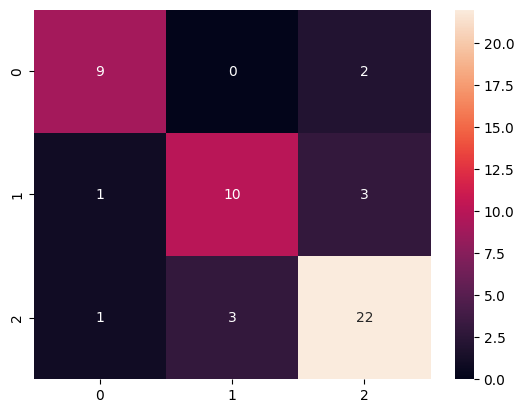

In [135]:
cm = confusion_matrix(
    y_test,
    knn_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [136]:
scores = cross_val_score(
    knn,
    X_cls,
    y,
    cv=5
)

print("CV Scores:", scores)
print("Mean:", scores.mean())

CV Scores: [0.85294118 0.91176471 0.87878788 0.75757576 0.81818182]
Mean: 0.8438502673796793


## K-Means Clustering

In [137]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Segment"] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Segment
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


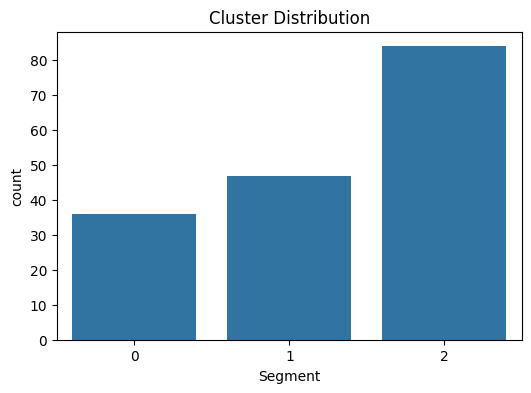

Segment
2    84
1    47
0    36
Name: count, dtype: int64


In [138]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Segment"]
)

plt.title("Cluster Distribution")
plt.show()

print(df["Segment"].value_counts())

## Pca visualization

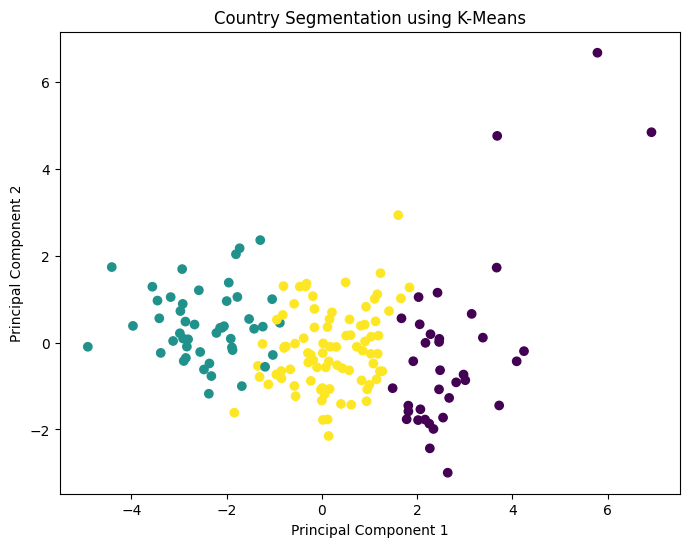

In [139]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Country Segmentation using K-Means")

plt.show()

## DBSCAN Clustering

In [140]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN"] = db_labels

print(pd.Series(db_labels).value_counts())

 0    137
-1     30
Name: count, dtype: int64


In [141]:
cluster_profile = df.groupby("Segment").mean(
    numeric_only=True
)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN
Segment,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


In [142]:
X_cls = df.drop(
    ["country", "Segment", "DBSCAN"],
    axis=1
)

y = df["Segment"]

print(X_cls.shape)

(167, 9)


## Train-Test Split

In [143]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## Logistic regression

In [144]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9019607843137255


In [145]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=7
)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(
    y_test,
    knn_pred
)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.803921568627451


## Random forest

In [146]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9411764705882353


## xgboost

In [147]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9411764705882353


## Ensemble Model

In [148]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn),
        ('rf', rf)
    ],
    voting='hard'
)

ensemble.fit(
    X_train,
    y_train
)

ensemble_pred = ensemble.predict(
    X_test
)

ensemble_acc = accuracy_score(
    y_test,
    ensemble_pred
)

print(
    "Ensemble Accuracy:",
    ensemble_acc
)

Ensemble Accuracy: 0.9215686274509803


## Model comparision

In [149]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "XGBoost",
        "Ensemble"
    ],
    "Accuracy":[
        lr_acc,
        knn_acc,
        rf_acc,
        xgb_acc,
        ensemble_acc
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

                 Model  Accuracy
2        Random Forest  0.941176
3              XGBoost  0.941176
4             Ensemble  0.921569
0  Logistic Regression  0.901961
1                  KNN  0.803922


In [150]:
print(
    classification_report(
        y_test,
        ensemble_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       1.00      0.93      0.96        14
           2       0.89      0.96      0.93        26

    accuracy                           0.92        51
   macro avg       0.93      0.90      0.92        51
weighted avg       0.92      0.92      0.92        51



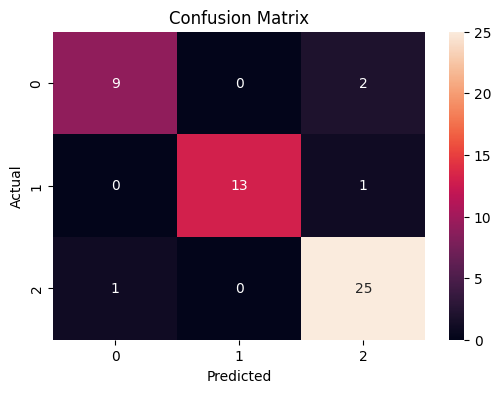

In [151]:
cm = confusion_matrix(
    y_test,
    ensemble_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.show()

## Cross validation

In [152]:
scores = cross_val_score(
    ensemble,
    X_cls,
    y,
    cv=5
)

print(scores)

print(
    "Mean Accuracy:",
    scores.mean()
)

[0.97058824 1.         0.96969697 0.87878788 0.96969697]
Mean Accuracy: 0.9577540106951872


In [156]:
importance = pd.DataFrame({
    "Feature": X_cls.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

      Feature  Importance
0  child_mort    0.232311
7   total_fer    0.212691
8        gdpp    0.211484
4      income    0.160620
6  life_expec    0.126752
2      health    0.022098
3     imports    0.012656
1     exports    0.011549
5   inflation    0.009841


## Predict on New Data

In [154]:
new_country = pd.DataFrame([{
    'child_mort':20,
    'exports':35,
    'health':6,
    'imports':40,
    'income':15000,
    'inflation':5,
    'life_expec':72,
    'total_fer':2.5,
    'gdpp':12000
}])

prediction = ensemble.predict(
    new_country
)

segment_map = {
    0:"Developed",
    1:"Developing",
    2:"Underdeveloped"
}

print(
    "Predicted Segment:",
    prediction[0]
)

print(
    "Category:",
    segment_map[prediction[0]]
)

Predicted Segment: 2
Category: Underdeveloped


## Save model

In [158]:
import joblib

joblib.dump(
    ensemble,
    "customer_intelligence_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']